In [9]:
#! pip uninstall torch torchvision torchaudio -y

#! pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#! pip install --upgrade torch torchvision torchaudio
#! pip3 install torchvision --index-url https://download.pytorch.org/whl/cu121

In [10]:
! pip show torchvision
import torchvision
print(torchvision.__file__)

Name: torchvision
Version: 0.20.1+cu121
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.10/dist-packages
Requires: numpy, pillow, torch
Required-by: fastai, ultralytics
/usr/local/lib/python3.10/dist-packages/torchvision/__init__.py


In [11]:
import torch
print(torch.cuda.is_available())  # ¿True?
print(torch.version.cuda)         # ¿"11.8", "12.1", etc?|
print(torch.cuda.get_device_name(0))  # ¿Detecta tu GPU?
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True
12.1
NVIDIA RTX A4000


In [12]:
#! pip install opencv-python pandas

In [13]:
import os
import cv2
import pandas as pd

ruta_base = "/root/Trabajo/Cedulas/imagenes_cedula_peq"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())

                                                Path             Label  \
0  /root/Trabajo/Cedulas/imagenes_cedula_peq/Cedu...  Cedula_Guayaquil   
1  /root/Trabajo/Cedulas/imagenes_cedula_peq/Cedu...  Cedula_Guayaquil   
2  /root/Trabajo/Cedulas/imagenes_cedula_peq/Cedu...  Cedula_Guayaquil   
3  /root/Trabajo/Cedulas/imagenes_cedula_peq/Cedu...  Cedula_Guayaquil   
4  /root/Trabajo/Cedulas/imagenes_cedula_peq/Cedu...  Cedula_Guayaquil   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


<ipython-input-14-bb73095a9177>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')


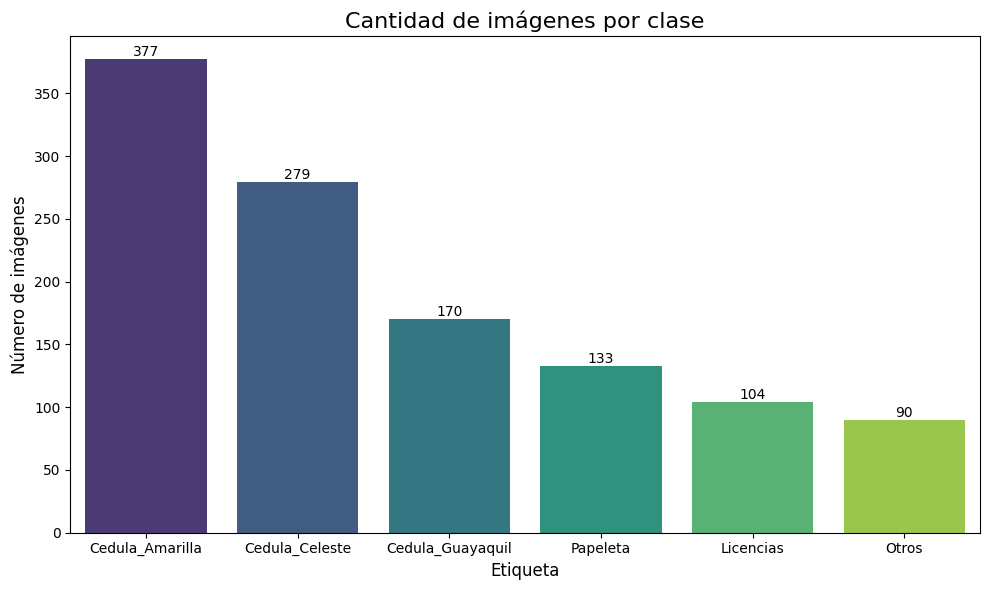

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo de imágenes por clase
conteo = df['Label'].value_counts().reset_index()
conteo.columns = ['Label', 'Cantidad']

# Crear figura
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Label', y='Cantidad', data=conteo, palette='viridis')

# Mostrar los valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',               # texto
                (p.get_x() + p.get_width() / 2., height),  # posición
                ha='center', va='bottom', fontsize=10)

# Personalización del gráfico
plt.title('Cantidad de imágenes por clase', fontsize=16)
plt.xlabel('Etiqueta', fontsize=12)
plt.ylabel('Número de imágenes', fontsize=12)
plt.tight_layout()
plt.show()


In [15]:
import torch
from torchvision import models, transforms
import torch.nn as nn
import cv2

# 1. Modelo MobileNetV2 con avgpool
mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V2")
feature_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))  # ↓ reduce a (batch_size, 1280, 1, 1)
)
feature_extractor.eval()

# 2. Preprocesamiento estándar (IMAGENET compatible)
preprocess = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],  # mejor usar valores de imagenet
                             std=[0.229, 0.224, 0.225]),
    ]
)

# 3. Extraer vectores
features_list = []
labels_list = []

def extract_feature_vector(image_path: str) -> torch.Tensor:
    """
    Extrae un vector de características de tamaño (1280,) de una imagen usando MobileNetV2.

    Args:
        image_path (str): Ruta al archivo de imagen.

    Returns:
        np.ndarray: Vector de características de tamaño (1280,) o None si hay error.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"[WARNING] No se pudo cargar la imagen: {image_path}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = preprocess(img_rgb).unsqueeze(0)

    with torch.no_grad():
        features = feature_extractor(input_tensor)
        vector = features.view(-1).numpy()  # → shape: (1280,)
    
    return vector

for i, row in df.iterrows():
    image_pros=extract_feature_vector(row["Path"])
    features_list.append(image_pros)
    labels_list.append(row["Label_decode"])



In [16]:
print(features_list[0].shape)

(1280,)


In [17]:
from sklearn.manifold import TSNE
import numpy as np
# Convertir a array
X = np.array(features_list)
y = np.array(labels_list)

# Ejecutar t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)


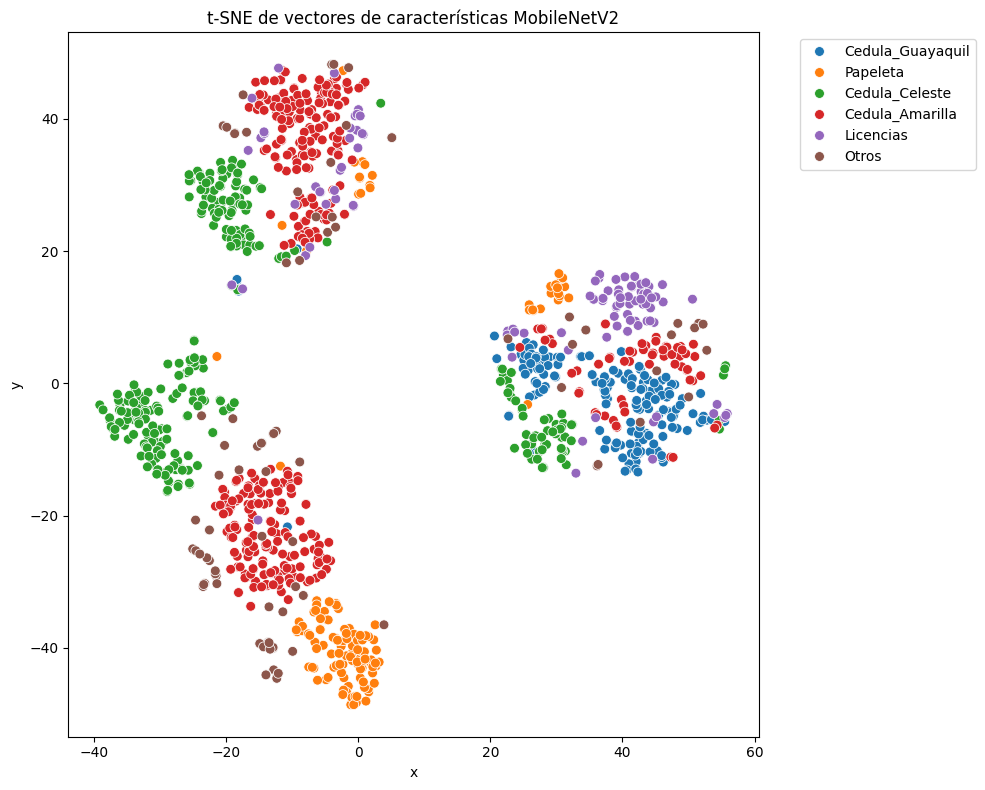

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
y_label=np.array(df["Label"])
# Crear DataFrame para graficar
tsne_df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "Label": y_label
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="Label", palette="tab10", s=50)
plt.title("t-SNE de vectores de características MobileNetV2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [19]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import lightning as L
from sklearn.model_selection import train_test_split, StratifiedKFold


class MyDataModule(L.LightningDataModule):
    def __init__(self, X, y, batch_size=64, clases=1, kfold=2):
        super().__init__()
        self.batch_size = batch_size
        self.num_classes = clases
        self.kfold = kfold
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.folder = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

    def prepare_data(self):
        # Split data once
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=0.3,
            random_state=42,
            stratify=self.y,
            shuffle=True,
        )
        self.kfolder = list(self.folder.split(X=self.X_train, y=self.y_train))
        self.input_shape = self.X_train.shape[1]  # assuming shape = [N, features]

    def setup(self, stage=None, n_fold=0):
        if stage == "fit" or stage is None:
            train_idx, val_idx = self.kfolder[n_fold]
            X_train_fold = self.X_train[train_idx]
            y_train_fold = self.y_train[train_idx]
            X_val_fold = self.X_train[val_idx]
            y_val_fold = self.y_train[val_idx]

            self.train_dataset = TensorDataset(X_train_fold, y_train_fold)
            self.val_dataset = TensorDataset(X_val_fold, y_val_fold)

        if stage == "test" or stage is None:
            self.test_dataset = TensorDataset(self.X_test, self.y_test)

        if stage == "predict" or stage is None:
            self.predict_dataset = self.test_dataset

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self, data=None):
        if data == None:
            return DataLoader(
                self.predict_dataset,
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            return DataLoader(
                data,
                batch_size=self.batch_size,
                shuffle=False,
            )

In [20]:
dataset=MyDataModule(X,y,clases=6,kfold=5)
dataset.prepare_data()
dataset.setup()

In [ ]:
from torchmetrics import F1Score

class Mymodel(L.LightningModule):
    def __init__(self, input_shape, num_classes, hidden_units, lambda_reg=0.0001, regularization=None):
        super().__init__()
        self.save_hyperparameters()
        self.hidden_units = hidden_units
        self.lambda_reg = lambda_reg
        self.regularization = regularization

        layers = [nn.Flatten()]
        for units in hidden_units:
            layers.append(nn.Linear(input_shape, units))
            layers.append(nn.BatchNorm1d(units))
            layers.append(nn.LeakyReLU(negative_slope=0.01))
            input_shape = units
        
        layers.append(nn.Linear(input_shape, num_classes))
        layers.append(nn.LogSoftmax(dim=1))

        self.classifier = nn.Sequential(*layers)
        
        self.loss = nn.NLLLoss()
        self.f1 = F1Score(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.classifier(x)

    def configure_optimizers(self):
        if self.regularization == "L2":
            return torch.optim.Adam(self.parameters(), lr=0.0001, weight_decay=self.lambda_reg)
        else:
            return torch.optim.Adam(self.parameters(), lr=0.0001)

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('train_loss', loss, on_step=True, on_epoch=True, logger=True)
        self.log('train_f1', f1_score, on_step=True, on_epoch=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('val_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('val_f1', f1_score, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.loss(logits, labels)
        preds = torch.argmax(logits, dim=1)
        f1_score = self.f1(preds, labels)

        self.log('test_loss', loss, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        self.log('test_f1', f1_score, on_step=True, on_epoch=True, logger=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x  = batch
        log_probs = self.forward(x)
        probs = torch.exp(log_probs)
        return probs

    def on_validation_epoch_start(self):
        self.f1.reset()


In [22]:
lambda_ = 0.001
epochs = 1000  # Number of epochs for training
#hidden_units = [254, 254, 254]
#regul = "L1"
hiddens_units = [[32, 32, 32], [64, 64, 64], [128, 128, 128], [16, 32, 64, 128]]
reguls = ["L1", "L2"]

In [ ]:

import os
import pandas as pd

df_metrics = pd.DataFrame()

for regul in reguls:
    for hidden_units in hiddens_units:
        results = [[], []]  # [f1_scores, losses]
        for i in range(dataset.kfold):
            model = Mymodel(
                input_shape=dataset.input_shape,
                num_classes=dataset.num_classes,
                hidden_units=hidden_units,
                lambda_reg=lambda_,
                regularization=regul,
            )

            early_stop_callback = L.pytorch.callbacks.EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=5,
            )

            checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
                save_top_k=2,
                save_last=True,
                monitor="val_loss",
                mode="min",
            )

            callbacks = [early_stop_callback, checkpoint_callback]

            name = ",".join([str(n) for n in hidden_units])
            path = f"{name}_{regul}"

            fold_dir = os.path.join("checkpoints", path)
            os.makedirs(fold_dir, exist_ok=True)

            trainer = L.Trainer(
                max_epochs=epochs,
                callbacks=callbacks,
                accelerator="gpu" if device.type == "cuda" else "cpu",
                devices=1,
                default_root_dir=fold_dir,
            )

            dataset.setup(stage="fit", n_fold=i)

            trainer.fit(
                model,
                train_dataloaders=dataset.train_dataloader(),
                val_dataloaders=dataset.val_dataloader(),
            )

            result_val = trainer.validate(
                model,
                dataloaders=dataset.val_dataloader(),
                ckpt_path="best",
            )
            result_test = trainer.test(
                model,
                dataloaders=dataset.test_dataloader(),
                ckpt_path="best",
            )

            results[0].append(result_test[0]["test_f1_epoch"])
            results[1].append(result_test[0]["test_loss_epoch"])

        # Agregar columnas al DataFrame
        col_f1 = f"{name}_{regul}_f1"
        col_loss = f"{name}_{regul}_loss"
        df_metrics[col_f1] = results[0]
        df_metrics[col_loss] = results[1]


NameError: name 'a' is not defined

In [ ]:
print(df_metrics)


   32,32,32_L1_f1  32,32,32_L1_loss  64,64,64_L1_f1  64,64,64_L1_loss  \
0        0.945087          0.460537        0.968208          0.262990   
1        0.947977          0.312787        0.962428          0.241894   
2        0.956647          0.304334        0.973988          0.203223   
3        0.971098          0.408303        0.959538          0.201377   
4        0.971098          0.389040        0.968208          0.196484   

   128,128,128_L1_f1  128,128,128_L1_loss  16,32,64,128_L1_f1  \
0           0.965318             0.186657            0.953757   
1           0.950867             0.178057            0.921965   
2           0.973988             0.165248            0.924855   
3           0.956647             0.207307            0.924855   
4           0.956647             0.171698            0.947977   

   16,32,64,128_L1_loss  32,32,32_L2_f1  32,32,32_L2_loss  64,64,64_L2_f1  \
0              0.227021        0.965318          0.378387        0.971098   
1              0

In [24]:
model = Mymodel.load_from_checkpoint("/root/Trabajo/Cedulas/checkpoints/128,128,128_L1/lightning_logs/version_2/checkpoints/last.ckpt")
model.eval()  # Cambia a modo de evaluación


Mymodel(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1280, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): LeakyReLU(negative_slope=0.01)
    (10): Linear(in_features=128, out_features=6, bias=True)
    (11): LogSoftmax(dim=1)
  )
  (loss): NLLLoss()
  (f1): MulticlassF1Score()
)

In [25]:
ruta_base = "/root/Trabajo/Training_Cedulas2.0 (2)/Training_Cedulas2.0/images/val"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)
for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            data.append(
                {
                    "Path": ruta_completa,
                    "PIL": cv2.cvtColor(cv2.imread(ruta_completa), cv2.COLOR_BGR2RGB),
                    "Vectores": extract_feature_vector(ruta_completa),
                }
            )
df_predict = pd.DataFrame(data)

In [75]:

df_sample=df_predict.sample(n=20,random_state=25)


In [76]:
trainer = L.Trainer()
predicciones = trainer.predict(model, dataloaders=dataset.predict_dataloader(data=list(df_sample["Vectores"])))  # dataset es tu DataModule
# 4. Procesar predicciones
predicciones= list(predicciones)
for batch in predicciones:
    clases_predichas = torch.argmax(batch, dim=1)
    print((clases_predichas))
predicciones=predicciones[0]
print((predicciones))

INFO: Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' 

Predicting: |          | 0/? [00:00<?, ?it/s]

tensor([2, 1, 3, 5, 2, 2, 2, 2, 2, 4, 2, 3, 2, 4, 3, 2, 2, 3, 3, 2])
tensor([[4.0894e-03, 3.2189e-03, 9.8526e-01, 1.7065e-03, 2.8573e-03, 2.8719e-03],
        [1.8637e-01, 4.0734e-01, 4.8740e-02, 1.7134e-01, 1.4314e-01, 4.3075e-02],
        [1.3287e-02, 1.3016e-02, 1.5057e-02, 9.3182e-01, 1.3200e-02, 1.3616e-02],
        [8.5459e-02, 2.4422e-02, 4.0857e-02, 1.4553e-01, 1.6104e-02, 6.8762e-01],
        [2.9484e-03, 3.5132e-03, 9.8455e-01, 1.8670e-03, 3.3496e-03, 3.7689e-03],
        [9.1328e-02, 3.5938e-02, 4.5865e-01, 2.4099e-01, 6.5148e-02, 1.0795e-01],
        [6.4289e-03, 2.4164e-03, 9.8050e-01, 2.3664e-03, 2.7641e-03, 5.5256e-03],
        [4.9666e-04, 5.5124e-04, 9.9713e-01, 2.6342e-04, 6.0709e-04, 9.4867e-04],
        [3.5803e-02, 1.8609e-02, 8.1925e-01, 2.7898e-02, 1.3595e-02, 8.4846e-02],
        [1.3809e-02, 6.3404e-02, 1.4904e-02, 1.3794e-02, 7.7754e-01, 1.1655e-01],
        [2.1618e-03, 3.3802e-03, 9.8798e-01, 1.7307e-03, 2.3662e-03, 2.3819e-03],
        [3.6658e-02, 2.8019e-

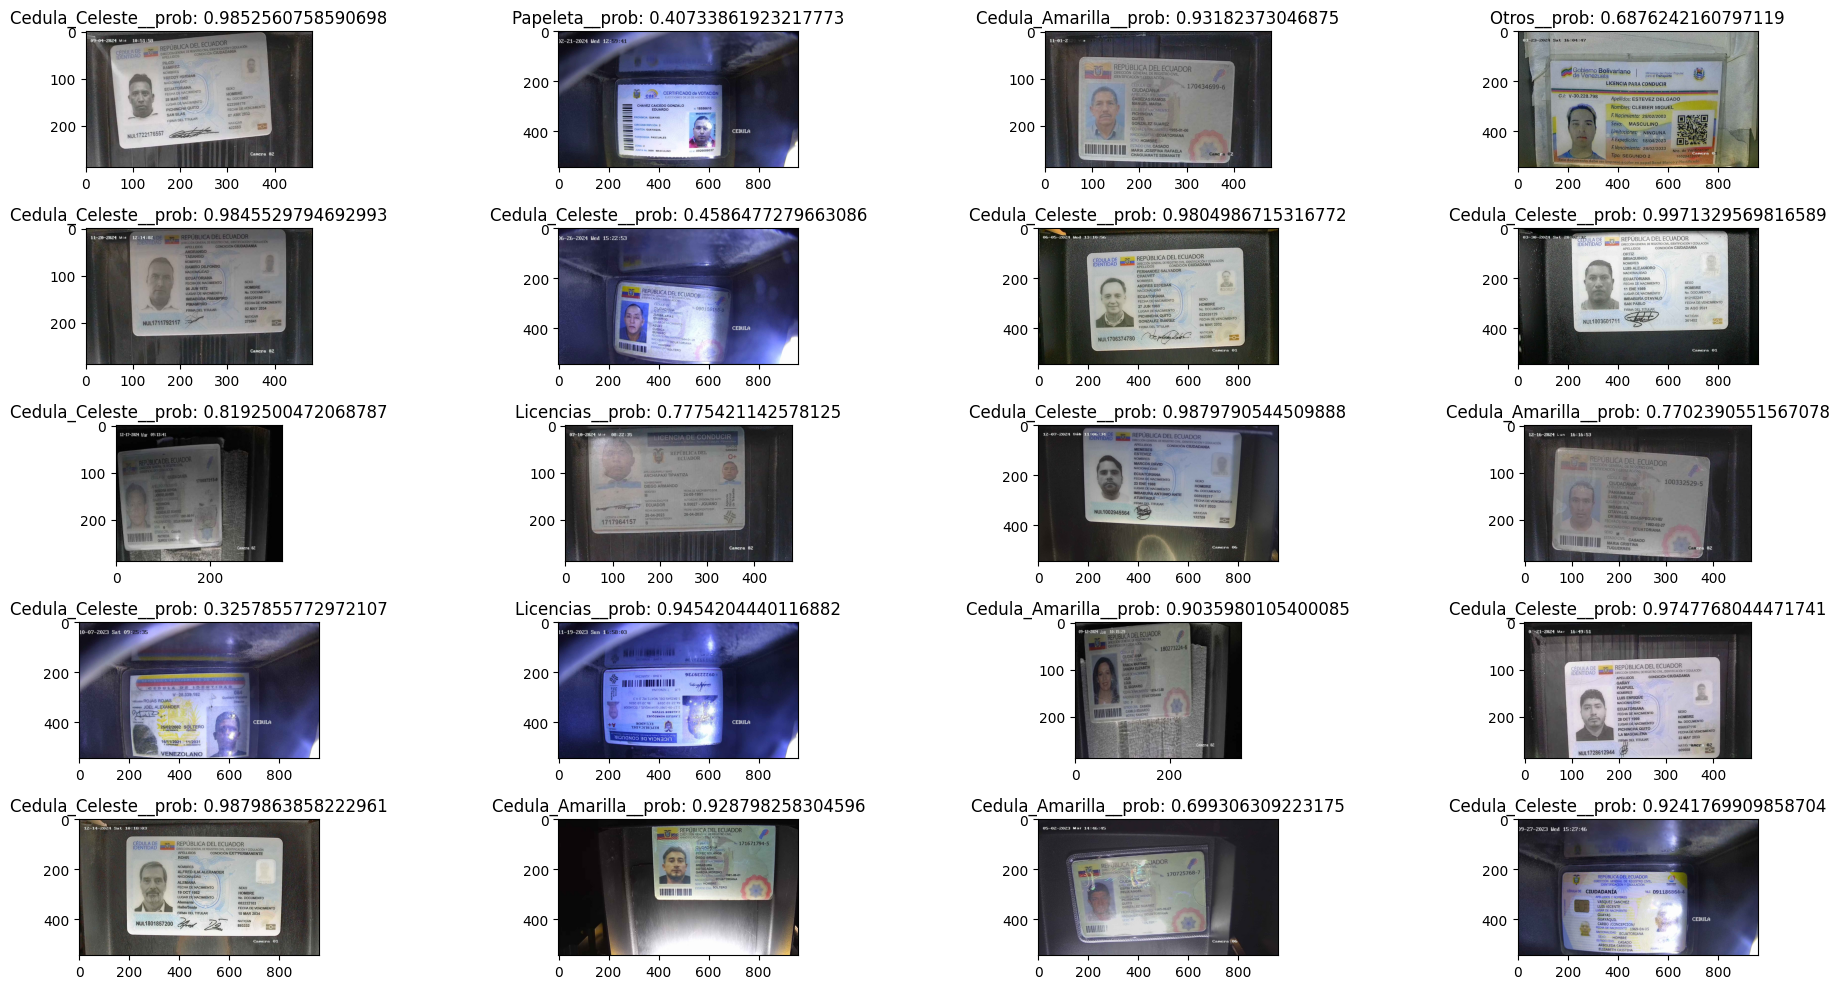

In [78]:
fig, axes = plt.subplots(ncols=4, nrows=5, figsize=(20,10))
axes = axes.flatten()
for i in range(len(predicciones)):
    axes[i].imshow(df_sample["PIL"].iloc[i])
    porcent=max(predicciones[i])
    axes[i].set_title(f"{stratiffy[clases_predichas[i]]}__prob: {porcent}")
plt.tight_layout()